#### Importing libraries

In [88]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

#### Reading the data file

In [89]:
df = pd.read_csv('salary_dataset.csv')
df.head()

,age,experience_years,education_level,hours_per_week,salary
0,24,3,3,60,78234
1,44,13,1,57,102791
2,37,13,1,27,80394
3,48,1,3,48,81549
4,52,27,3,22,154251


#### finding the corelation matrix for numerical columns

In [90]:
df.corr()

,age,experience_years,education_level,hours_per_week,salary
age,1.000000,0.636041,0.001789,-0.000311,0.627545
experience_years,0.636041,1.000000,-0.003707,-0.002763,0.897474
education_level,0.001789,-0.003707,1.000000,-0.006800,0.402238
hours_per_week,-0.000311,-0.002763,-0.006800,1.000000,0.133885
salary,0.627545,0.897474,0.402238,0.133885,1.000000


#### visualizing the outliers

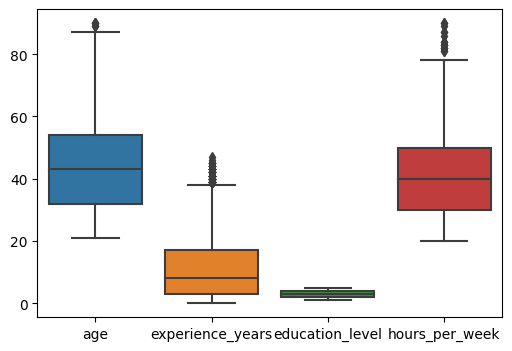

In [91]:
plt.figure(figsize=(6, 4))
sns.boxplot(df[['age', 'experience_years', 'education_level', 'hours_per_week']])
plt.show()

##### Creating objects for scaling classes

In [92]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()
minMax_scaler = MinMaxScaler()

#### segrigation the features and target columns

In [93]:
x = df.drop(columns='salary')
y = df['salary']

##### spliting the data into train-test

In [94]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

##### scaling the columns which has less outliers

In [95]:
xtrain[['age', 'education_level']] = standard_scaler.fit_transform(xtrain[['age', 'education_level']])
xtest[['age', 'education_level']] = standard_scaler.transform(xtest[['age', 'education_level']])

#### scaling the object which has more outliers

In [96]:
xtrain[['experience_years', 'hours_per_week']] = robust_scaler.fit_transform(xtrain[['experience_years','hours_per_week']])
xtest[['experience_years', 'hours_per_week']] = robust_scaler.transform(xtest[['experience_years', 'hours_per_week']])

In [97]:
xtrain

,age,experience_years,education_level,hours_per_week
9254,1.359990,-0.142857,1.400753,0.70
1561,1.132567,2.000000,-1.418905,1.00
1670,-0.535202,0.285714,-0.009076,-0.40
6087,-0.383587,-0.214286,0.695839,0.35
6669,-1.596510,-0.571429,-1.418905,0.00
...,...,...,...,...
5734,-0.156164,0.500000,-0.009076,0.60
5191,-0.990049,0.000000,0.695839,0.30
5390,-0.383587,-0.071429,0.695839,0.20
860,1.284182,-0.428571,-1.418905,-0.80
